# Sky localization maps

In [10]:
# 🎨 Matplotlib Style Configuration (Light & Dark Mode Compatible)
# Run this cell once at the beginning

import matplotlib
import matplotlib.pyplot as plt

# Universal matplotlib settings that work in both light and dark mode
matplotlib.rcParams.update({
    # High-quality output
    'figure.dpi': 100,              # Display DPI (screen)
    'savefig.dpi': 300,             # Save DPI (high quality for web)
    'figure.figsize': (10, 6),      # Default figure size in inches
    
    # Transparent backgrounds - adapts to page theme
    'savefig.transparent': True,
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    
    # Dark gray text - readable on both white and dark backgrounds
    'text.color': '#2d3748',        # Dark gray
    'axes.labelcolor': '#2d3748',
    'axes.edgecolor': '#4a5568',
    'xtick.color': '#2d3748',
    'ytick.color': '#2d3748',
    'axes.titlecolor': '#1a202c',   # Very dark gray (almost black)
    
    # Legend styling
    'legend.edgecolor': '#4a5568',
    'legend.facecolor': 'none',
    
    # Grid styling - subtle gray
    'grid.color': '#718096',
    'grid.alpha': 0.3,
})


In [11]:
import numpy as np
import healpy as hp
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
%matplotlib inline

## Load a Flat HEALPix Sky Map 
Example: S251112cm

In [12]:
import gzip
import urllib.request
from io import BytesIO
import healpy as hp
import tempfile
import os

# Download and read directly from GraceDB without saving permanently
url = 'https://gracedb.ligo.org/api/superevents/S251112cm/files/bayestar.fits.gz'

print(f"Downloading from {url}...")
with urllib.request.urlopen(url) as response:
    compressed_data = response.read()

print("Decompressing in memory...")
with gzip.open(BytesIO(compressed_data), 'rb') as f_in:
    fits_data = f_in.read()

# Create temporary file for healpy to read
with tempfile.NamedTemporaryFile(suffix='.fits', delete=False) as tmp:
    tmp.write(fits_data)
    tmp_path = tmp.name

try:
    # Use healpy to read the map properly (handles NESTED/RING ordering automatically)
    print("Reading HEALPix map...")
    m, header = hp.read_map(tmp_path, h=True, verbose=False)
    header = dict(header)
finally:
    # Clean up temporary file
    os.unlink(tmp_path)

print(f"✅ Map loaded successfully!")
print(f"Nside = {header['NSIDE']}, Ordering = {header['ORDERING']}")
print(f"Number of pixels = {len(m):,}")


Decompressing in memory...
Reading HEALPix map...
✅ Map loaded successfully!
Nside = 512, Ordering = NESTED
Number of pixels = 3,145,728


## Understanding HEALPix Map Orderings

HEALPix maps can be stored in two different orderings:

- **RING ordering**: Pixels are arranged in horizontal rings of constant latitude, numbered from north to south pole
- **NESTED ordering**: Pixels follow a hierarchical quad-tree structure, where nearby pixels have nearby indices. **Best for computation, indexing, and hierarchical methods**


In [13]:
nside = hp.get_nside(m)        # or header['NSIDE']
npix = hp.nside2npix(nside)
print(f"Nside: {nside}")
print(f"Total pixels on the sky: {npix:,}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Nside: 512
Total pixels on the sky: 3,145,728
Pixel area: 0.0131 deg²


$$N_{\text{pix}} = 12 \, \text{NSIDE}^2$$

## 3. Visualize the Sky Map (Mollweide Projection)

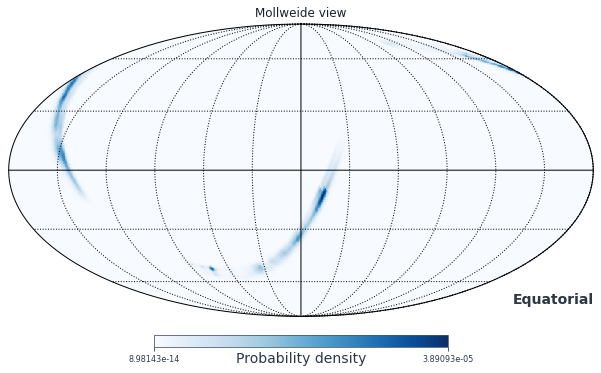

In [14]:
hp.mollview(m, unit="Probability density", coord='C', cmap='Blues')
hp.graticule()

# Make plot transparent and text dark gray for universal compatibility
fig = plt.gcf()
fig.patch.set_alpha(0)
text_color = '#2d3748'  # Dark gray - works on both light and dark backgrounds

for ax in fig.axes:
    ax.patch.set_alpha(0)
    # Make all text elements dark gray
    for text in ax.texts:
        text.set_color(text_color)
    ax.tick_params(colors=text_color, which='both', labelsize=8)
    
    # Colorbar text
    if hasattr(ax, 'collections'):
        for coll in ax.collections:
            if hasattr(coll, 'colorbar') and coll.colorbar:
                coll.colorbar.ax.tick_params(colors=text_color)
                coll.colorbar.ax.yaxis.label.set_color(text_color)

### Careful about rotated axes!! Zero RA point is at the center of the map

## Find the Highest-Probability Pixel & Convert to Sky Coordinates

In [15]:
ipix_max = np.argmax(m)
theta, phi = hp.pix2ang(nside, ipix_max)
ra_deg = np.degrees(phi)
dec_deg = 90 - np.degrees(theta)

print(f"Highest probability pixel index: {ipix_max}")
print(f"RA, Dec = {ra_deg:.4f}°, {dec_deg:.4f}°")

Highest probability pixel index: 1940405
RA, Dec = 346.8164°, -13.4781°


## Compute Credible Levels (50%, 90%, etc.)

In [16]:
# Sort pixels by probability density (descending)
sorted_prob = np.sort(m)[::-1]

# Cumulative probability
cumsum = np.cumsum(sorted_prob)
cumsum /= cumsum[-1]  # normalize to 1

print(f"Number of pixels in 90% region: {np.count_nonzero(cumsum <= 0.90)}")
print(f"The area of the 90% credible region is {np.count_nonzero(cumsum <= 0.90) * hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Number of pixels in 90% region: 93049
The area of the 90% credible region is 1220.2412 deg²


In [17]:
def get_credible_level(ra, dec, skymap_data, nside):
    """
    Get the credible level for a given RA and Dec position.
    
    Parameters:
    ra: Right Ascension in degrees
    dec: Declination in degrees
    skymap_data: HEALPix probability map
    nside: HEALPix nside parameter
    
    Returns:
    Credible level as a percentage
    """
    # Convert RA, Dec to theta, phi
    theta_query = np.radians(90 - dec)
    phi_query = np.radians(ra)
    
    # Get pixel index
    ipix_query = hp.ang2pix(nside, theta_query, phi_query)
    
    # Get probability at this pixel
    prob_at_pixel = skymap_data[ipix_query]
    
    # Calculate credible level
    sorted_prob_desc = np.sort(skymap_data)[::-1]
    cumsum_prob = np.cumsum(sorted_prob_desc)
    cumsum_prob /= cumsum_prob[-1]

    # I ASSIGNED TO EACH PIXEL THE CREDIBLE LEVEL BASED ON ITS PROBABILITY DENSITY, AFTER SORTING
    
    # Find where this probability falls in the sorted array
    credible_level = cumsum_prob[sorted_prob_desc >= prob_at_pixel][-1] * 100
    
    return credible_level, prob_at_pixel

# Example usage: check the highest probability pixel
ra_test = 180
dec_test = 55
cl, prob = get_credible_level(ra_test, dec_test, m, nside)
print(f"RA={ra_test:.4f}°, Dec={dec_test:.4f}°")
print(f"Probability density: {prob:.6e}")
print(f"Credible level: {cl:.2f}%")

RA=180.0000°, Dec=55.0000°
Probability density: 6.402603e-06
Credible level: 73.88%


## Downgrade to Lower Resolution

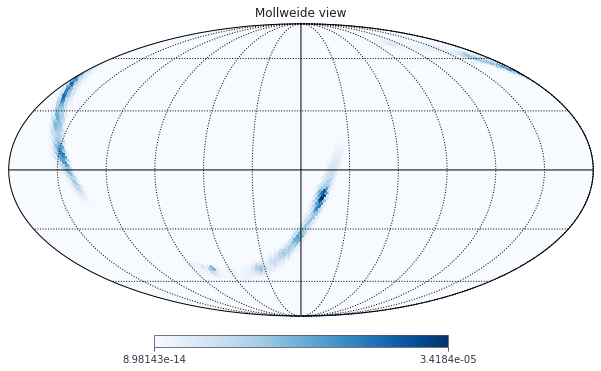

In [18]:
# Configure matplotlib for transparent background
import matplotlib
matplotlib.rcParams['savefig.transparent'] = True

nside_low = 32
m_low = hp.ud_grade(m, nside_out=nside_low)  # averages probability density correctly

hp.mollview(m_low,cmap='Blues')
hp.graticule()
plt.show()

In [19]:
# Sort pixels by probability density (descending)
sorted_prob = np.sort(m)[::-1]

# Cumulative probability
cumsum = np.cumsum(sorted_prob)
cumsum /= cumsum[-1]  # normalize to 1

print(f"Number of pixels in 90% region: {np.count_nonzero(cumsum <= 0.90)}")
print(f"The area of the 90% credible region is {np.count_nonzero(cumsum <= 0.90) * hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Number of pixels in 90% region: 93049
The area of the 90% credible region is 1220.2412 deg²


In [20]:
def get_credible_level(ra, dec, skymap_data, nside):
    """
    Get the credible level for a given RA and Dec position.
    
    Parameters:
    ra: Right Ascension in degrees
    dec: Declination in degrees
    skymap_data: HEALPix probability map
    nside: HEALPix nside parameter
    
    Returns:
    Credible level as a percentage
    """
    # Convert RA, Dec to theta, phi
    theta_query = np.radians(90 - dec)
    phi_query = np.radians(ra)
    
    # Get pixel index
    ipix_query = hp.ang2pix(nside, theta_query, phi_query)
    
    # Get probability at this pixel
    prob_at_pixel = skymap_data[ipix_query]
    
    # Calculate credible level
    sorted_prob_desc = np.sort(skymap_data)[::-1]
    cumsum_prob = np.cumsum(sorted_prob_desc)
    cumsum_prob /= cumsum_prob[-1]

    # I ASSIGNED TO EACH PIXEL THE CREDIBLE LEVEL BASED ON ITS PROBABILITY DENSITY, AFTER SORTING
    
    # Find where this probability falls in the sorted array
    credible_level = cumsum_prob[sorted_prob_desc >= prob_at_pixel][-1] * 100
    
    return credible_level, prob_at_pixel

# Example usage: check the highest probability pixel
ra_test = 180
dec_test = 55
cl, prob = get_credible_level(ra_test, dec_test, m, nside)
print(f"RA={ra_test:.4f}°, Dec={dec_test:.4f}°")
print(f"Probability density: {prob:.6e}")
print(f"Credible level: {cl:.2f}%")

RA=180.0000°, Dec=55.0000°
Probability density: 6.402603e-06
Credible level: 73.88%


## Integrated probability inside a circle

In [21]:
ra_test = 180
dec_test = 55
theta = np.radians(90 - dec_test)
phi = np.radians(ra_test)
radius = np.radians(5)  # example radius of 5 degrees
xyz = hp.ang2vec(theta, phi)
ipix_disc = hp.query_disc(nside, xyz, radius)
print(f"{m[ipix_disc].sum()*100:.2f}%")

4.84%


## Integrated probability inside a polygon

In [22]:
# Convert polygon vertices from RA, Dec to Cartesian coordinates
# Create a square polygon centered at ra_test, dec_test with side 10 degrees
half_side = 5  # half of 10 degrees
vertices_radec = [[ra_test - half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test + half_side], 
                  [ra_test - half_side, dec_test + half_side]]

xyz = np.array([hp.ang2vec(np.radians(90 - dec), np.radians(ra)) 
                for ra, dec in vertices_radec])
ipix_poly = hp.query_polygon(nside, xyz)
print(f"{m[ipix_poly].sum()*100:.2f}%")

3.39%


# Multi-order resolution maps

Each region of the sky is divide in sub-regions, and the process is done iteretively until it's reached a resolution of the same spatial scale of the variations of the map in that region of the sky. Coarser grid where the probability has a smoother change, finer where more information is contained

<img src="images/healpix-adaptive-mesh.svg" alt="Swift and Fermi mission comparison" width="300"/>

Then we have 2 info: the level of resolution of the sub-grid (given by nside) and the order of the pixel inside that sub-grid. This is compressed in a single index

$ uniq = ipix + 4 * nside^2 $   

In [23]:
from astropy.table import QTable
from astropy import units as u
import astropy_healpix as ah
import numpy as np

skymap = QTable.read('bayestar.multiorder.fits,1')

## Most Probable Sky Location

In [24]:
i = np.argmax(skymap['PROBDENSITY'])
uniq = skymap[i]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

512

In [25]:
uniq = skymap[0]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

16

This shows that around the peak of the probability map we have a high density of information, hence we require more resolution

In [26]:
ra, dec = ah.healpix_to_lonlat(ipix, nside, order='nested')
ra.deg, dec.deg

(44.99999999999999, 2.388015463268777)